# 09 Machine Learning

## Purpose

This notebook evaluates whether a simple predictive model can add useful forward-looking information to the Germany tourism competitiveness analysis.

The machine-learning task is to predict Germany's monthly foreign overnight stays using information that would already be available before the target month.

The objective is not to replace the descriptive, statistical, or strategic analyses completed in earlier notebooks. Instead, the model is used as an additional decision-support tool for understanding whether recent tourism patterns contain enough predictive structure to estimate short-term overnight-stay demand.

## Predictive Question

Can Germany's monthly foreign overnight stays be predicted reasonably well from historical tourism patterns, seasonality, and lagged visitor activity?

## Target Variable

The prediction target is:

- Monthly foreign overnight stays in Germany

## Candidate Predictors

Potential predictors include:

- Previous month's foreign overnight stays
- Overnight stays in the same month of the previous year
- Previous month's foreign arrivals
- Foreign arrivals in the same month of the previous year
- Calendar month
- Time trend
- Seasonal features derived from calendar month

Only information available before the month being predicted will be used.

## Modeling Principles

The modeling process follows several safeguards:

1. Time order will be preserved. Random train-test splitting will not be used because it would allow future observations to influence model evaluation.
2. A simple seasonal-naive forecast will be used as the baseline.
3. Machine-learning models must outperform or meaningfully improve upon the baseline to be considered useful.
4. Model complexity will remain limited because the monthly dataset is relatively small.
5. Performance will be evaluated using MAE, RMSE, and R² where appropriate.
6. Predictions will be interpreted as model estimates rather than causal effects.
7. The model will not be presented as a definitive full-year 2026 forecast unless its evaluation supports such use.

## Analytical Limitation

The available historical period is relatively short and includes the post-pandemic tourism recovery period. Structural changes during this period may reduce the stability of historical relationships.

For this reason, predictive results should be treated as exploratory decision-support evidence rather than high-confidence forecasts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

project_root = Path.cwd().parent

clean_dir = (
    project_root
    / "data"
    / "clean"
)

processed_dir = (
    project_root
    / "data"
    / "processed"
)

figures_dir = (
    project_root
    / "figures"
)

In [2]:
germany_nights = pd.read_csv(
    clean_dir
    / "germany_foreign_nights_monthly_clean.csv"
)

germany_arrivals = pd.read_csv(
    clean_dir
    / "germany_foreign_arrivals_monthly_clean.csv"
)

print(
    "Germany nights:",
    germany_nights.shape
)

print(
    "Germany arrivals:",
    germany_arrivals.shape
)

display(
    germany_nights.head()
)

display(
    germany_arrivals.head()
)

Germany nights: (67, 11)
Germany arrivals: (67, 11)


,country_code,country,period,foreign_nights,status,year,month,value_available,date,months_available,complete_12_month_year
0,DE,Germany,2021-01,692238.0,NaN,2021,1,True,2021-01-01,12,True
1,DE,Germany,2021-02,771308.0,NaN,2021,2,True,2021-02-01,12,True
2,DE,Germany,2021-03,930822.0,NaN,2021,3,True,2021-03-01,12,True
3,DE,Germany,2021-04,878134.0,NaN,2021,4,True,2021-04-01,12,True
4,DE,Germany,2021-05,1029929.0,NaN,2021,5,True,2021-05-01,12,True


,country_code,country,period,foreign_arrivals,status,year,month,value_available,date,months_available,complete_12_month_year
0,DE,Germany,2021-01,169984.0,NaN,2021,1,True,2021-01-01,12,True
1,DE,Germany,2021-02,186270.0,NaN,2021,2,True,2021-02-01,12,True
2,DE,Germany,2021-03,230216.0,NaN,2021,3,True,2021-03-01,12,True
3,DE,Germany,2021-04,219128.0,NaN,2021,4,True,2021-04-01,12,True
4,DE,Germany,2021-05,291267.0,NaN,2021,5,True,2021-05-01,12,True


In [3]:
monthly_model = (
    germany_nights[
        [
            "period",
            "year",
            "month",
            "date",
            "foreign_nights"
        ]
    ]
    .merge(
        germany_arrivals[
            [
                "period",
                "foreign_arrivals"
            ]
        ],
        on="period",
        how="inner",
        validate="one_to_one"
    )
)

monthly_model[
    "date"
] = pd.to_datetime(
    monthly_model[
        "date"
    ]
)

monthly_model = (
    monthly_model
    .sort_values(
        "date"
    )
    .reset_index(
        drop=True
    )
)

display(
    monthly_model.tail(15)
)

print(
    "Model table shape:",
    monthly_model.shape
)

,period,year,month,date,foreign_nights,foreign_arrivals
52,2025-05,2025,5,2025-05-01,7484744.0,3329016.0
53,2025-06,2025,6,2025-06-01,7530964.0,3447435.0
54,2025-07,2025,7,2025-07-01,10358796.0,4666150.0
55,2025-08,2025,8,2025-08-01,9689151.0,4229612.0
56,2025-09,2025,9,2025-09-01,7674317.0,3451143.0
57,2025-10,2025,10,2025-10-01,7195093.0,3171850.0
58,2025-11,2025,11,2025-11-01,5590732.0,2550385.0
59,2025-12,2025,12,2025-12-01,6582972.0,3045185.0
60,2026-01,2026,1,2026-01-01,4277203.0,1938956.0
61,2026-02,2026,2,2026-02-01,5078278.0,2271693.0


Model table shape: (67, 6)


In [4]:
monthly_model = (
    monthly_model[
        monthly_model[
            "foreign_nights"
        ].notna()
        &
        monthly_model[
            "foreign_arrivals"
        ].notna()
    ]
    .copy()
)

print(
    "Usable monthly observations:",
    len(
        monthly_model
    )
)

print(
    "Period:",
    monthly_model[
        "date"
    ].min(),
    "to",
    monthly_model[
        "date"
    ].max()
)

display(
    monthly_model.tail()
)

Usable monthly observations: 66
Period: 2021-01-01 00:00:00 to 2026-06-01 00:00:00


,period,year,month,date,foreign_nights,foreign_arrivals
61,2026-02,2026,2,2026-02-01,5078278.0,2271693.0
62,2026-03,2026,3,2026-03-01,5197078.0,2341823.0
63,2026-04,2026,4,2026-04-01,6596278.0,2934984.0
64,2026-05,2026,5,2026-05-01,7446648.0,3353419.0
65,2026-06,2026,6,2026-06-01,7653746.0,3505228.0


In [5]:
monthly_model["nights_lag_1"] = (
    monthly_model["foreign_nights"]
    .shift(1)
)

monthly_model["nights_lag_12"] = (
    monthly_model["foreign_nights"]
    .shift(12)
)

monthly_model["arrivals_lag_1"] = (
    monthly_model["foreign_arrivals"]
    .shift(1)
)

monthly_model["arrivals_lag_12"] = (
    monthly_model["foreign_arrivals"]
    .shift(12)
)

monthly_model["time_index"] = np.arange(
    len(monthly_model)
)

monthly_model["month_sin"] = np.sin(
    2 * np.pi
    * monthly_model["month"]
    / 12
)

monthly_model["month_cos"] = np.cos(
    2 * np.pi
    * monthly_model["month"]
    / 12
)

display(
    monthly_model[
        [
            "date",
            "foreign_nights",
            "foreign_arrivals",
            "nights_lag_1",
            "nights_lag_12",
            "arrivals_lag_1",
            "arrivals_lag_12",
            "time_index",
            "month_sin",
            "month_cos"
        ]
    ]
    .head(15)
)

,date,foreign_nights,foreign_arrivals,nights_lag_1,nights_lag_12,arrivals_lag_1,arrivals_lag_12,time_index,month_sin,month_cos
0,2021-01-01,692238.0,169984.0,NaN,NaN,NaN,NaN,0,5.000000e-01,8.660254e-01
1,2021-02-01,771308.0,186270.0,692238.0,NaN,169984.0,NaN,1,8.660254e-01,5.000000e-01
2,2021-03-01,930822.0,230216.0,771308.0,NaN,186270.0,NaN,2,1.000000e+00,6.123234e-17
3,2021-04-01,878134.0,219128.0,930822.0,NaN,230216.0,NaN,3,8.660254e-01,-5.000000e-01
4,2021-05-01,1029929.0,291267.0,878134.0,NaN,219128.0,NaN,4,5.000000e-01,-8.660254e-01
5,2021-06-01,1837486.0,669924.0,1029929.0,NaN,291267.0,NaN,5,1.224647e-16,-1.000000e+00
6,2021-07-01,4500507.0,1855788.0,1837486.0,NaN,669924.0,NaN,6,-5.000000e-01,-8.660254e-01
7,2021-08-01,5009685.0,2041142.0,4500507.0,NaN,1855788.0,NaN,7,-8.660254e-01,-5.000000e-01
8,2021-09-01,4365165.0,1789764.0,5009685.0,NaN,2041142.0,NaN,8,-1.000000e+00,-1.836970e-16
9,2021-10-01,4697357.0,1884542.0,4365165.0,NaN,1789764.0,NaN,9,-8.660254e-01,5.000000e-01


In [6]:
feature_columns = [
    "nights_lag_1",
    "nights_lag_12",
    "arrivals_lag_1",
    "arrivals_lag_12",
    "time_index",
    "month_sin",
    "month_cos"
]

print(
    monthly_model[
        feature_columns
    ]
    .isna()
    .sum()
)

nights_lag_1        1
nights_lag_12      12
arrivals_lag_1      1
arrivals_lag_12    12
time_index          0
month_sin           0
month_cos           0
dtype: int64


In [7]:
ml_data = (
    monthly_model[
        [
            "date",
            "year",
            "month",
            "foreign_nights"
        ]
        + feature_columns
    ]
    .dropna()
    .reset_index(
        drop=True
    )
)

print(
    "Final ML observations:",
    len(ml_data)
)

print(
    "ML period:",
    ml_data["date"].min(),
    "to",
    ml_data["date"].max()
)

display(
    ml_data.head()
)

display(
    ml_data.tail()
)

Final ML observations: 54
ML period: 2022-01-01 00:00:00 to 2026-06-01 00:00:00


,date,year,month,foreign_nights,nights_lag_1,nights_lag_12,arrivals_lag_1,arrivals_lag_12,time_index,month_sin,month_cos
0,2022-01-01,2022,1,1912992.0,2530151.0,692238.0,969189.0,169984.0,12,0.500000,8.660254e-01
1,2022-02-01,2022,2,2542987.0,1912992.0,771308.0,701139.0,186270.0,13,0.866025,5.000000e-01
2,2022-03-01,2022,3,3296966.0,2542987.0,930822.0,1007194.0,230216.0,14,1.000000,6.123234e-17
3,2022-04-01,2022,4,4886184.0,3296966.0,878134.0,1282377.0,219128.0,15,0.866025,-5.000000e-01
4,2022-05-01,2022,5,6027813.0,4886184.0,1029929.0,2007686.0,291267.0,16,0.500000,-8.660254e-01


,date,year,month,foreign_nights,nights_lag_1,nights_lag_12,arrivals_lag_1,arrivals_lag_12,time_index,month_sin,month_cos
49,2026-02-01,2026,2,5078278.0,4277203.0,4949805.0,1938956.0,2180842.0,61,8.660254e-01,5.000000e-01
50,2026-03-01,2026,3,5197078.0,5078278.0,5220357.0,2271693.0,2294956.0,62,1.000000e+00,6.123234e-17
51,2026-04-01,2026,4,6596278.0,5197078.0,6556296.0,2341823.0,2898714.0,63,8.660254e-01,-5.000000e-01
52,2026-05-01,2026,5,7446648.0,6596278.0,7484744.0,2934984.0,3329016.0,64,5.000000e-01,-8.660254e-01
53,2026-06-01,2026,6,7653746.0,7446648.0,7530964.0,3353419.0,3447435.0,65,1.224647e-16,-1.000000e+00


In [8]:
train_data = (
    ml_data[
        ml_data["date"] < "2025-01-01"
    ]
    .copy()
)

test_data = (
    ml_data[
        ml_data["date"] >= "2025-01-01"
    ]
    .copy()
)

print(
    "Training observations:",
    len(train_data)
)

print(
    "Training period:",
    train_data["date"].min(),
    "to",
    train_data["date"].max()
)

print()

print(
    "Test observations:",
    len(test_data)
)

print(
    "Test period:",
    test_data["date"].min(),
    "to",
    test_data["date"].max()
)

Training observations: 36
Training period: 2022-01-01 00:00:00 to 2024-12-01 00:00:00

Test observations: 18
Test period: 2025-01-01 00:00:00 to 2026-06-01 00:00:00


In [9]:
y_test = test_data["foreign_nights"]

baseline_predictions = (
    test_data["nights_lag_12"]
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_mse = mean_squared_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    baseline_mse
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print(
    f"Baseline MAE: {baseline_mae:,.0f}"
)

print(
    f"Baseline RMSE: {baseline_rmse:,.0f}"
)

print(
    f"Baseline R²: {baseline_r2:.3f}"
)

Baseline MAE: 199,489
Baseline RMSE: 325,249
Baseline R²: 0.962


In [10]:
baseline_results = test_data[
    [
        "date",
        "foreign_nights"
    ]
].copy()

baseline_results[
    "baseline_prediction"
] = baseline_predictions.values

baseline_results[
    "error"
] = (
    baseline_results["foreign_nights"]
    - baseline_results["baseline_prediction"]
)

baseline_results[
    "absolute_error"
] = (
    baseline_results["error"]
    .abs()
)

baseline_results[
    "percentage_error"
] = (
    baseline_results["error"]
    / baseline_results["foreign_nights"]
    * 100
)

display(
    baseline_results.round(2)
)

/var/folders/3_/6lgqyskd5v55bylpxy1jbmzr0000gn/T/ipykernel_99086/1137306946.py:35: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  baseline_results.round(2)


,date,foreign_nights,baseline_prediction,error,absolute_error,percentage_error
36,2025-01-01,4242218.0,4364278.0,-122060.0,122060.0,-2.88
37,2025-02-01,4949805.0,5025740.0,-75935.0,75935.0,-1.53
38,2025-03-01,5220357.0,5479515.0,-259158.0,259158.0,-4.96
39,2025-04-01,6556296.0,6334532.0,221764.0,221764.0,3.38
40,2025-05-01,7484744.0,7412549.0,72195.0,72195.0,0.96
41,2025-06-01,7530964.0,8707934.0,-1176970.0,1176970.0,-15.63
42,2025-07-01,10358796.0,10588926.0,-230130.0,230130.0,-2.22
43,2025-08-01,9689151.0,10087476.0,-398325.0,398325.0,-4.11
44,2025-09-01,7674317.0,7837030.0,-162713.0,162713.0,-2.12
45,2025-10-01,7195093.0,6961927.0,233166.0,233166.0,3.24


In [11]:
baseline_mape = (
    (
        baseline_results[
            "absolute_error"
        ]
        / baseline_results[
            "foreign_nights"
        ]
    )
    .mean()
    * 100
)

print(
    f"Baseline MAPE: {baseline_mape:.2f}%"
)

Baseline MAPE: 2.86%


In [12]:
model_features = [
    "nights_lag_1",
    "nights_lag_12",
    "arrivals_lag_1",
    "arrivals_lag_12",
    "time_index",
    "month_sin",
    "month_cos"
]

X_train = train_data[
    model_features
].copy()

X_test = test_data[
    model_features
].copy()

y_train = train_data[
    "foreign_nights"
].copy()

y_test = test_data[
    "foreign_nights"
].copy()

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (36, 7)
X_test: (18, 7)
y_train: (36,)
y_test: (18,)


In [13]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

linear_mape = (
    np.mean(
        np.abs(
            (
                y_test.values
                - linear_predictions
            )
            / y_test.values
        )
    )
    * 100
)

print(
    f"Linear Regression MAE: {linear_mae:,.0f}"
)

print(
    f"Linear Regression RMSE: {linear_rmse:,.0f}"
)

print(
    f"Linear Regression R²: {linear_r2:.3f}"
)

print(
    f"Linear Regression MAPE: {linear_mape:.2f}%"
)

Linear Regression MAE: 1,206,310
Linear Regression RMSE: 1,360,566
Linear Regression R²: 0.327
Linear Regression MAPE: 19.11%


In [14]:
model_comparison = pd.DataFrame({
    "model": [
        "Seasonal Naive",
        "Linear Regression"
    ],
    "MAE": [
        baseline_mae,
        linear_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse
    ],
    "MAPE_pct": [
        baseline_mape,
        linear_mape
    ],
    "R2": [
        baseline_r2,
        linear_r2
    ]
})

display(
    model_comparison.round(3)
)

,model,MAE,RMSE,MAPE_pct,R2
0,Seasonal Naive,199489.111,325248.830,2.859,0.962
1,Linear Regression,1206310.016,1360566.052,19.113,0.327


In [15]:
linear_improvement = pd.DataFrame({
    "metric": [
        "MAE",
        "RMSE",
        "MAPE"
    ],
    "baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_mape
    ],
    "linear_regression": [
        linear_mae,
        linear_rmse,
        linear_mape
    ]
})

linear_improvement[
    "improvement_pct"
] = (
    (
        linear_improvement["baseline"]
        - linear_improvement["linear_regression"]
    )
    / linear_improvement["baseline"]
    * 100
)

display(
    linear_improvement.round(2)
)

,metric,baseline,linear_regression,improvement_pct
0,MAE,199489.11,1206310.02,-504.70
1,RMSE,325248.83,1360566.05,-318.32
2,MAPE,2.86,19.11,-568.48


In [16]:
linear_results = test_data[
    [
        "date",
        "foreign_nights"
    ]
].copy()

linear_results[
    "baseline_prediction"
] = baseline_predictions.values

linear_results[
    "linear_prediction"
] = linear_predictions

linear_results[
    "linear_error"
] = (
    linear_results["foreign_nights"]
    - linear_results["linear_prediction"]
)

linear_results[
    "linear_absolute_error"
] = (
    linear_results["linear_error"]
    .abs()
)

display(
    linear_results
)

,date,foreign_nights,baseline_prediction,linear_prediction,linear_error,linear_absolute_error
36,2025-01-01,4242218.0,4364278.0,4.706216e+06,-4.639980e+05,4.639980e+05
37,2025-02-01,4949805.0,5025740.0,3.951190e+06,9.986148e+05,9.986148e+05
38,2025-03-01,5220357.0,5479515.0,4.506621e+06,7.137357e+05,7.137357e+05
39,2025-04-01,6556296.0,6334532.0,5.144586e+06,1.411710e+06,1.411710e+06
40,2025-05-01,7484744.0,7412549.0,6.217697e+06,1.267047e+06,1.267047e+06
41,2025-06-01,7530964.0,8707934.0,8.004431e+06,-4.734665e+05,4.734665e+05
42,2025-07-01,10358796.0,10588926.0,9.505592e+06,8.532045e+05,8.532045e+05
43,2025-08-01,9689151.0,10087476.0,9.042138e+06,6.470132e+05,6.470132e+05
44,2025-09-01,7674317.0,7837030.0,7.138331e+06,5.359863e+05,5.359863e+05
45,2025-10-01,7195093.0,6961927.0,5.873357e+06,1.321736e+06,1.321736e+06


In [17]:
linear_coefficients = pd.DataFrame({
    "feature": model_features,
    "coefficient": linear_model.coef_
})

linear_coefficients[
    "absolute_coefficient"
] = (
    linear_coefficients[
        "coefficient"
    ]
    .abs()
)

display(
    linear_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
)

,feature,coefficient,absolute_coefficient
4,time_index,-116759.124701,116759.124701
6,month_cos,-6614.380508,6614.380508
5,month_sin,-1862.720653,1862.720653
3,arrivals_lag_12,4.761497,4.761497
2,arrivals_lag_1,3.562461,3.562461
1,nights_lag_12,-1.438448,1.438448
0,nights_lag_1,-1.205451,1.205451


### Linear Regression Interpretation

Linear Regression did not improve predictive performance relative to the seasonal-naive benchmark.

On the January 2025 to June 2026 test period, Linear Regression produced an MAE of approximately 1.21 million nights, RMSE of 1.36 million, MAPE of 19.11%, and R² of 0.327.

In comparison, the seasonal-naive benchmark achieved an MAE of approximately 199,000 nights, RMSE of 325,000, MAPE of 2.86%, and R² of 0.962.

The regression model therefore increased MAE by approximately 505%, RMSE by 318%, and MAPE by 568% relative to the baseline.

The results indicate that the additional linear combination of lagged tourism activity, time trend, and seasonal features did not generalize effectively to the later test period. The prediction errors also became particularly large during several 2026 months.

This does not imply that the individual predictors are unimportant for tourism performance. Rather, it indicates that this particular linear specification, estimated from a relatively small and structurally changing post-pandemic dataset, is not competitive with the much simpler seasonal-naive forecasting rule.

The seasonal-naive model therefore remains the benchmark to beat.

In [18]:
random_forest = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=2,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

rf_mape = (
    np.mean(
        np.abs(
            (
                y_test.values
                - rf_predictions
            )
            / y_test.values
        )
    )
    * 100
)

print(
    f"Random Forest MAE: {rf_mae:,.0f}"
)

print(
    f"Random Forest RMSE: {rf_rmse:,.0f}"
)

print(
    f"Random Forest R²: {rf_r2:.3f}"
)

print(
    f"Random Forest MAPE: {rf_mape:.2f}%"
)

Random Forest MAE: 633,246
Random Forest RMSE: 800,050
Random Forest R²: 0.767
Random Forest MAPE: 11.08%


In [19]:
model_comparison = pd.DataFrame({
    "model": [
        "Seasonal Naive",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "MAPE_pct": [
        baseline_mape,
        linear_mape,
        rf_mape
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

display(
    model_comparison
    .sort_values("RMSE")
    .round(3)
)

,model,MAE,RMSE,MAPE_pct,R2
0,Seasonal Naive,199489.111,325248.830,2.859,0.962
2,Random Forest,633245.881,800049.911,11.084,0.767
1,Linear Regression,1206310.016,1360566.052,19.113,0.327


In [20]:
rf_improvement = pd.DataFrame({
    "metric": [
        "MAE",
        "RMSE",
        "MAPE"
    ],
    "baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_mape
    ],
    "random_forest": [
        rf_mae,
        rf_rmse,
        rf_mape
    ]
})

rf_improvement[
    "improvement_pct"
] = (
    (
        rf_improvement["baseline"]
        - rf_improvement["random_forest"]
    )
    / rf_improvement["baseline"]
    * 100
)

display(
    rf_improvement.round(2)
)

,metric,baseline,random_forest,improvement_pct
0,MAE,199489.11,633245.88,-217.43
1,RMSE,325248.83,800049.91,-145.98
2,MAPE,2.86,11.08,-287.67


In [21]:
rf_results = test_data[
    [
        "date",
        "foreign_nights"
    ]
].copy()

rf_results[
    "baseline_prediction"
] = baseline_predictions.values

rf_results[
    "random_forest_prediction"
] = rf_predictions

rf_results[
    "rf_error"
] = (
    rf_results["foreign_nights"]
    - rf_results["random_forest_prediction"]
)

rf_results[
    "rf_absolute_error"
] = (
    rf_results["rf_error"]
    .abs()
)

display(
    rf_results
)

,date,foreign_nights,baseline_prediction,random_forest_prediction,rf_error,rf_absolute_error
36,2025-01-01,4242218.0,4364278.0,5.706316e+06,-1.464098e+06,1.464098e+06
37,2025-02-01,4949805.0,5025740.0,5.497313e+06,-5.475081e+05,5.475081e+05
38,2025-03-01,5220357.0,5479515.0,5.869849e+06,-6.494925e+05,6.494925e+05
39,2025-04-01,6556296.0,6334532.0,6.317945e+06,2.383507e+05,2.383507e+05
40,2025-05-01,7484744.0,7412549.0,7.728065e+06,-2.433214e+05,2.433214e+05
41,2025-06-01,7530964.0,8707934.0,9.404505e+06,-1.873541e+06,1.873541e+06
42,2025-07-01,10358796.0,10588926.0,9.748877e+06,6.099192e+05,6.099192e+05
43,2025-08-01,9689151.0,10087476.0,9.850052e+06,-1.609006e+05,1.609006e+05
44,2025-09-01,7674317.0,7837030.0,8.032045e+06,-3.577276e+05,3.577276e+05
45,2025-10-01,7195093.0,6961927.0,7.087631e+06,1.074619e+05,1.074619e+05


In [22]:
rf_feature_importance = pd.DataFrame({
    "feature": model_features,
    "importance": random_forest.feature_importances_
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    rf_feature_importance.round(4)
)

,feature,importance
0,nights_lag_1,0.2870
1,arrivals_lag_1,0.1789
2,nights_lag_12,0.1782
3,arrivals_lag_12,0.1664
4,month_cos,0.1203
5,time_index,0.0465
6,month_sin,0.0228


### Random Forest Interpretation

Random Forest improved substantially over Linear Regression but did not outperform the seasonal-naive benchmark.

On the January 2025 to June 2026 test period, Random Forest achieved an MAE of approximately 633,000 nights, RMSE of 800,000, MAPE of 11.08%, and R² of 0.767.

Although these results were considerably better than Linear Regression, Random Forest still produced approximately 217% higher MAE, 146% higher RMSE, and 288% higher MAPE than the seasonal-naive benchmark.

The Random Forest model relied most heavily on the previous month's overnight stays, followed by previous-month arrivals and the corresponding values from the same month one year earlier. These feature-importance values describe how the fitted model generated predictions and should not be interpreted as causal effects.

The results provide no evidence that the additional model complexity improves predictive performance relative to the simple seasonal benchmark on the held-out period.

In [23]:
validation_records = []

initial_train_size = 24

for i in range(
    initial_train_size,
    len(ml_data)
):
    rolling_train = ml_data.iloc[:i].copy()
    rolling_test = ml_data.iloc[[i]].copy()

    X_rolling_train = rolling_train[
        model_features
    ]

    y_rolling_train = rolling_train[
        "foreign_nights"
    ]

    X_rolling_test = rolling_test[
        model_features
    ]

    actual = rolling_test[
        "foreign_nights"
    ].iloc[0]

    baseline_prediction = rolling_test[
        "nights_lag_12"
    ].iloc[0]

    rolling_linear = LinearRegression()

    rolling_linear.fit(
        X_rolling_train,
        y_rolling_train
    )

    linear_prediction = rolling_linear.predict(
        X_rolling_test
    )[0]

    rolling_rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=2,
        random_state=42
    )

    rolling_rf.fit(
        X_rolling_train,
        y_rolling_train
    )

    rf_prediction = rolling_rf.predict(
        X_rolling_test
    )[0]

    validation_records.append({
        "date": rolling_test["date"].iloc[0],
        "actual": actual,
        "seasonal_naive": baseline_prediction,
        "linear_regression": linear_prediction,
        "random_forest": rf_prediction
    })

rolling_predictions = pd.DataFrame(
    validation_records
)

print(
    "Rolling validation observations:",
    len(rolling_predictions)
)

print(
    "Validation period:",
    rolling_predictions["date"].min(),
    "to",
    rolling_predictions["date"].max()
)

display(
    rolling_predictions.head()
)

display(
    rolling_predictions.tail()
)

Rolling validation observations: 30
Validation period: 2024-01-01 00:00:00 to 2026-06-01 00:00:00


,date,actual,seasonal_naive,linear_regression,random_forest
0,2024-01-01,4364278.0,3916585.0,5.253014e+06,5.699183e+06
1,2024-02-01,5025740.0,4775172.0,3.877747e+06,5.653147e+06
2,2024-03-01,5479515.0,5085489.0,4.607091e+06,5.612589e+06
3,2024-04-01,6334532.0,6307555.0,5.848736e+06,5.933640e+06
4,2024-05-01,7412549.0,7184273.0,6.807443e+06,7.181371e+06


,date,actual,seasonal_naive,linear_regression,random_forest
25,2026-02-01,5078278.0,4949805.0,3.868516e+06,5.287115e+06
26,2026-03-01,5197078.0,5220357.0,4.320303e+06,5.561870e+06
27,2026-04-01,6596278.0,6556296.0,5.366169e+06,6.526596e+06
28,2026-05-01,7446648.0,7484744.0,6.424661e+06,7.644813e+06
29,2026-06-01,7653746.0,7530964.0,7.039360e+06,7.914089e+06


In [24]:
rolling_metrics = []

for model_name in [
    "seasonal_naive",
    "linear_regression",
    "random_forest"
]:
    actual = rolling_predictions[
        "actual"
    ]

    predicted = rolling_predictions[
        model_name
    ]

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = (
        np.mean(
            np.abs(
                (
                    actual
                    - predicted
                )
                / actual
            )
        )
        * 100
    )

    r2 = r2_score(
        actual,
        predicted
    )

    rolling_metrics.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R2": r2
    })

rolling_model_comparison = (
    pd.DataFrame(
        rolling_metrics
    )
    .sort_values(
        "RMSE"
    )
    .reset_index(
        drop=True
    )
)

display(
    rolling_model_comparison.round(3)
)

,model,MAE,RMSE,MAPE_pct,R2
0,seasonal_naive,266833.700,391343.875,3.799,0.951
1,random_forest,560922.247,724000.904,9.110,0.831
2,linear_regression,706392.506,779041.680,11.119,0.804


In [25]:
rolling_predictions[
    "seasonal_naive_error"
] = (
    rolling_predictions["actual"]
    - rolling_predictions["seasonal_naive"]
).abs()

rolling_predictions[
    "linear_regression_error"
] = (
    rolling_predictions["actual"]
    - rolling_predictions["linear_regression"]
).abs()

rolling_predictions[
    "random_forest_error"
] = (
    rolling_predictions["actual"]
    - rolling_predictions["random_forest"]
).abs()

error_columns = [
    "seasonal_naive_error",
    "linear_regression_error",
    "random_forest_error"
]

rolling_predictions[
    "best_model"
] = (
    rolling_predictions[
        error_columns
    ]
    .idxmin(
        axis=1
    )
    .str.replace(
        "_error",
        "",
        regex=False
    )
)

monthly_wins = (
    rolling_predictions[
        "best_model"
    ]
    .value_counts()
    .rename_axis(
        "model"
    )
    .reset_index(
        name="months_best"
    )
)

monthly_wins[
    "share_pct"
] = (
    monthly_wins[
        "months_best"
    ]
    / len(
        rolling_predictions
    )
    * 100
)

display(
    monthly_wins
)

,model,months_best,share_pct
0,seasonal_naive,22,73.333333
1,random_forest,5,16.666667
2,linear_regression,3,10.000000


## Model Selection

Rolling-origin validation confirms the result observed in the fixed holdout evaluation.

Across 30 sequential out-of-sample monthly predictions from January 2024 through June 2026, the seasonal-naive benchmark achieved the strongest overall predictive performance:

- MAE: approximately 267,000 nights
- RMSE: approximately 391,000 nights
- MAPE: 3.80%
- R²: 0.951

Random Forest achieved a MAPE of 9.11% and R² of 0.831, while Linear Regression achieved a MAPE of 11.12% and R² of 0.804.

The seasonal-naive approach also produced the lowest absolute prediction error in 22 of the 30 validation months, or 73.3% of the evaluation period.

The consistency between the fixed holdout evaluation and rolling-origin validation provides strong evidence that Germany's monthly foreign overnight stays exhibit substantial annual seasonal persistence.

Neither Linear Regression nor Random Forest provided sufficient incremental predictive value to justify their additional complexity.

The seasonal-naive approach is therefore retained as the preferred forecasting benchmark for this dataset.

No further hyperparameter optimization is performed because repeatedly tuning more complex models against a small dataset would increase the risk of overfitting without a demonstrated business benefit.

In [26]:
rolling_predictions[
    "year"
] = rolling_predictions[
    "date"
].dt.year

yearly_baseline_performance = (
    rolling_predictions
    .groupby(
        "year"
    )
    .apply(
        lambda x: pd.Series({
            "observations": len(x),

            "MAE": mean_absolute_error(
                x["actual"],
                x["seasonal_naive"]
            ),

            "RMSE": np.sqrt(
                mean_squared_error(
                    x["actual"],
                    x["seasonal_naive"]
                )
            ),

            "MAPE_pct": (
                np.mean(
                    np.abs(
                        (
                            x["actual"]
                            - x["seasonal_naive"]
                        )
                        / x["actual"]
                    )
                )
                * 100
            )
        }),
        include_groups=False
    )
    .reset_index()
)

display(
    yearly_baseline_performance.round(2)
)

,year,observations,MAE,RMSE,MAPE_pct
0,2024,12.0,367850.58,473492.20,5.21
1,2025,12.0,266933.92,394521.44,3.75
2,2026,6.0,64599.50,77885.02,1.09


In [27]:
baseline_bias = (
    rolling_predictions["actual"]
    - rolling_predictions["seasonal_naive"]
).mean()

baseline_bias_pct = (
    (
        rolling_predictions["actual"]
        - rolling_predictions["seasonal_naive"]
    )
    / rolling_predictions["actual"]
).mean() * 100

print(
    f"Mean Baseline Error: {baseline_bias:,.0f} nights"
)

print(
    f"Mean Baseline Percentage Error: {baseline_bias_pct:.2f}%"
)

Mean Baseline Error: 98,729 nights
Mean Baseline Percentage Error: 1.46%


### Forecast Stability and Bias

The seasonal-naive benchmark remained effective across the rolling validation period and showed improving predictive performance in the most recent observations.

MAPE declined from 5.21% in 2024 to 3.75% in 2025 and 1.09% during January–June 2026. The 2026 result should be interpreted cautiously because it covers only six months rather than a complete year.

Across the full 30-month rolling validation period, the mean forecast error was approximately +98,700 nights, equivalent to +1.46% of actual monthly overnight stays. Because forecast error is defined as actual minus predicted, the positive value indicates a modest average tendency for the seasonal-naive benchmark to underpredict actual overnight stays.

The relatively small overall bias, combined with the model's strong rolling-validation performance, supports its use as a transparent short-term baseline projection. However, the projection should not be interpreted as a high-confidence forecast because the model assumes that the previous year's monthly seasonal pattern will broadly persist.

In [28]:
h2_2025 = (
    monthly_model[
        (monthly_model["year"] == 2025)
        &
        (monthly_model["month"].between(7, 12))
    ][
        [
            "month",
            "foreign_nights"
        ]
    ]
    .copy()
)

h2_2026_projection = (
    h2_2025
    .rename(
        columns={
            "foreign_nights":
            "projected_foreign_nights"
        }
    )
)

h2_2026_projection[
    "year"
] = 2026

h2_2026_projection[
    "date"
] = pd.to_datetime(
    {
        "year": h2_2026_projection["year"],
        "month": h2_2026_projection["month"],
        "day": 1
    }
)

h2_2026_projection[
    "projection_method"
] = "Seasonal Naive"

h2_2026_projection = (
    h2_2026_projection[
        [
            "date",
            "year",
            "month",
            "projected_foreign_nights",
            "projection_method"
        ]
    ]
    .reset_index(
        drop=True
    )
)

display(
    h2_2026_projection
)

,date,year,month,projected_foreign_nights,projection_method
0,2026-07-01,2026,7,10358796.0,Seasonal Naive
1,2026-08-01,2026,8,9689151.0,Seasonal Naive
2,2026-09-01,2026,9,7674317.0,Seasonal Naive
3,2026-10-01,2026,10,7195093.0,Seasonal Naive
4,2026-11-01,2026,11,5590732.0,Seasonal Naive
5,2026-12-01,2026,12,6582972.0,Seasonal Naive


In [29]:
h1_2026_actual = (
    monthly_model[
        (monthly_model["year"] == 2026)
        &
        (monthly_model["month"].between(1, 6))
    ]["foreign_nights"]
    .sum()
)

h2_2026_projected = (
    h2_2026_projection[
        "projected_foreign_nights"
    ]
    .sum()
)

full_year_2026_baseline = (
    h1_2026_actual
    + h2_2026_projected
)

full_year_2025_actual = (
    monthly_model[
        monthly_model["year"] == 2025
    ]["foreign_nights"]
    .sum()
)

full_year_growth_pct = (
    (
        full_year_2026_baseline
        / full_year_2025_actual
    )
    - 1
) * 100

print(
    f"H1 2026 Actual: "
    f"{h1_2026_actual:,.0f}"
)

print(
    f"H2 2026 Baseline Projection: "
    f"{h2_2026_projected:,.0f}"
)

print(
    f"Full-Year 2026 Baseline Scenario: "
    f"{full_year_2026_baseline:,.0f}"
)

print(
    f"Full-Year 2025 Actual: "
    f"{full_year_2025_actual:,.0f}"
)

print(
    f"Implied 2026 Growth: "
    f"{full_year_growth_pct:.2f}%"
)

H1 2026 Actual: 36,249,231
H2 2026 Baseline Projection: 47,091,061
Full-Year 2026 Baseline Scenario: 83,340,292
Full-Year 2025 Actual: 83,075,445
Implied 2026 Growth: 0.32%


In [30]:
h1_actual_table = (
    monthly_model[
        (monthly_model["year"] == 2026)
        &
        (monthly_model["month"].between(1, 6))
    ][
        [
            "date",
            "year",
            "month",
            "foreign_nights"
        ]
    ]
    .rename(
        columns={
            "foreign_nights":
            "foreign_nights_value"
        }
    )
    .copy()
)

h1_actual_table[
    "data_type"
] = "Actual"

h2_projection_table = (
    h2_2026_projection[
        [
            "date",
            "year",
            "month",
            "projected_foreign_nights"
        ]
    ]
    .rename(
        columns={
            "projected_foreign_nights":
            "foreign_nights_value"
        }
    )
    .copy()
)

h2_projection_table[
    "data_type"
] = "Seasonal Naive Projection"

germany_2026_actual_projection = (
    pd.concat(
        [
            h1_actual_table,
            h2_projection_table
        ],
        ignore_index=True
    )
    .sort_values(
        "date"
    )
    .reset_index(
        drop=True
    )
)

display(
    germany_2026_actual_projection
)

,date,year,month,foreign_nights_value,data_type
0,2026-01-01,2026,1,4277203.0,Actual
1,2026-02-01,2026,2,5078278.0,Actual
2,2026-03-01,2026,3,5197078.0,Actual
3,2026-04-01,2026,4,6596278.0,Actual
4,2026-05-01,2026,5,7446648.0,Actual
5,2026-06-01,2026,6,7653746.0,Actual
6,2026-07-01,2026,7,10358796.0,Seasonal Naive Projection
7,2026-08-01,2026,8,9689151.0,Seasonal Naive Projection
8,2026-09-01,2026,9,7674317.0,Seasonal Naive Projection
9,2026-10-01,2026,10,7195093.0,Seasonal Naive Projection


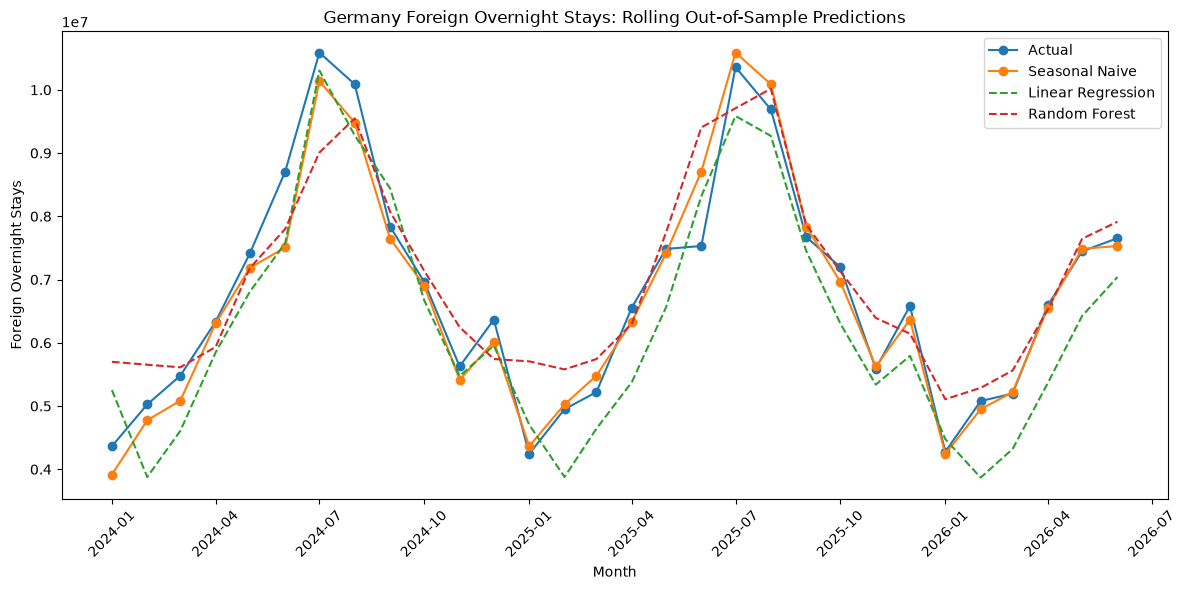

Saved: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/figures/germany_ml_rolling_model_comparison.png


In [31]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    rolling_predictions["date"],
    rolling_predictions["actual"],
    marker="o",
    label="Actual"
)

ax.plot(
    rolling_predictions["date"],
    rolling_predictions["seasonal_naive"],
    marker="o",
    label="Seasonal Naive"
)

ax.plot(
    rolling_predictions["date"],
    rolling_predictions["linear_regression"],
    linestyle="--",
    label="Linear Regression"
)

ax.plot(
    rolling_predictions["date"],
    rolling_predictions["random_forest"],
    linestyle="--",
    label="Random Forest"
)

ax.set_title(
    "Germany Foreign Overnight Stays: "
    "Rolling Out-of-Sample Predictions"
)

ax.set_xlabel(
    "Month"
)

ax.set_ylabel(
    "Foreign Overnight Stays"
)

ax.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

model_figure_path = (
    figures_dir
    / "germany_ml_rolling_model_comparison.png"
)

plt.savefig(
    model_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    model_figure_path
)

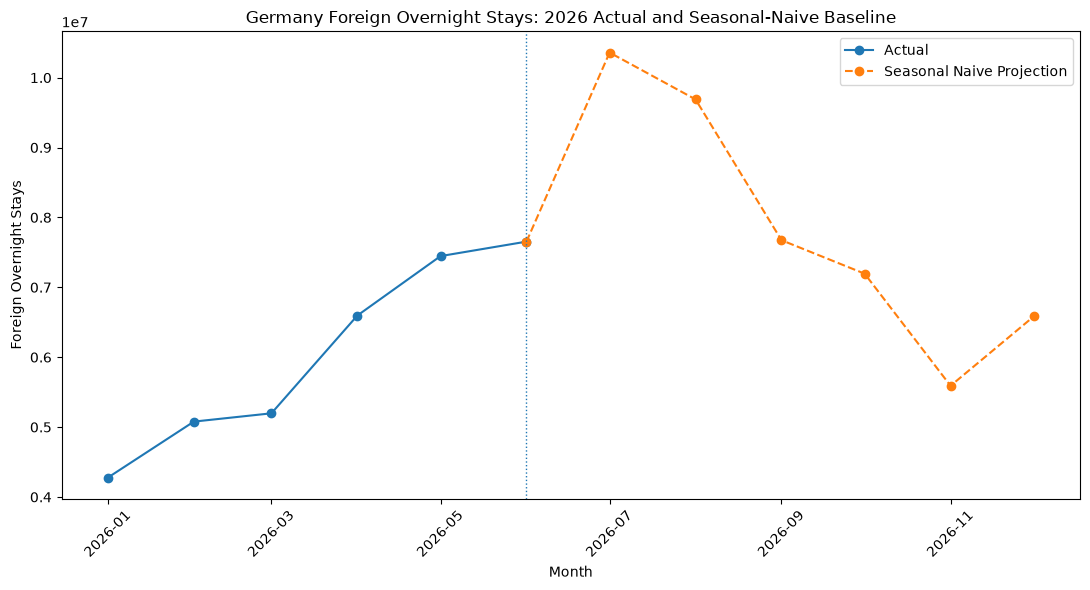

Saved: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/figures/germany_2026_actual_seasonal_naive_projection.png


In [32]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

actual_2026 = (
    germany_2026_actual_projection[
        germany_2026_actual_projection[
            "data_type"
        ] == "Actual"
    ]
)

projected_2026 = (
    germany_2026_actual_projection[
        germany_2026_actual_projection[
            "data_type"
        ] == "Seasonal Naive Projection"
    ]
)

ax.plot(
    actual_2026["date"],
    actual_2026["foreign_nights_value"],
    marker="o",
    label="Actual"
)

projection_dates = pd.concat(
    [
        actual_2026.tail(1)["date"],
        projected_2026["date"]
    ]
)

projection_values = pd.concat(
    [
        actual_2026.tail(1)[
            "foreign_nights_value"
        ],
        projected_2026[
            "foreign_nights_value"
        ]
    ]
)

ax.plot(
    projection_dates,
    projection_values,
    marker="o",
    linestyle="--",
    label="Seasonal Naive Projection"
)

ax.axvline(
    pd.Timestamp("2026-06-01"),
    linestyle=":",
    linewidth=1
)

ax.set_title(
    "Germany Foreign Overnight Stays: "
    "2026 Actual and Seasonal-Naive Baseline"
)

ax.set_xlabel(
    "Month"
)

ax.set_ylabel(
    "Foreign Overnight Stays"
)

ax.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

projection_figure_path = (
    figures_dir
    / "germany_2026_actual_seasonal_naive_projection.png"
)

plt.savefig(
    projection_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    projection_figure_path
)

In [33]:
forecast_scenario_summary = pd.DataFrame({
    "indicator": [
        "H1 2026 Actual",
        "H2 2026 Seasonal Naive Projection",
        "Full-Year 2026 Baseline Scenario",
        "Full-Year 2025 Actual",
        "Implied 2026 Growth (%)"
    ],
    "value": [
        h1_2026_actual,
        h2_2026_projected,
        full_year_2026_baseline,
        full_year_2025_actual,
        full_year_growth_pct
    ]
})

display(
    forecast_scenario_summary.round(2)
)

,indicator,value
0,H1 2026 Actual,36249231.00
1,H2 2026 Seasonal Naive Projection,47091061.00
2,Full-Year 2026 Baseline Scenario,83340292.00
3,Full-Year 2025 Actual,83075445.00
4,Implied 2026 Growth (%),0.32


In [34]:
model_comparison.to_csv(
    processed_dir
    / "germany_ml_holdout_model_comparison.csv",
    index=False
)

rolling_predictions.to_csv(
    processed_dir
    / "germany_ml_rolling_predictions.csv",
    index=False
)

rolling_model_comparison.to_csv(
    processed_dir
    / "germany_ml_rolling_model_comparison.csv",
    index=False
)

yearly_baseline_performance.to_csv(
    processed_dir
    / "germany_ml_baseline_performance_by_year.csv",
    index=False
)

rf_feature_importance.to_csv(
    processed_dir
    / "germany_ml_random_forest_feature_importance.csv",
    index=False
)

h2_2026_projection.to_csv(
    processed_dir
    / "germany_2026_h2_seasonal_naive_projection.csv",
    index=False
)

germany_2026_actual_projection.to_csv(
    processed_dir
    / "germany_2026_actual_projection_combined.csv",
    index=False
)

forecast_scenario_summary.to_csv(
    processed_dir
    / "germany_2026_baseline_scenario_summary.csv",
    index=False
)

print(
    "Notebook 09 processed outputs saved."
)

Notebook 09 processed outputs saved.


In [35]:
output_files = [
    "germany_ml_holdout_model_comparison.csv",
    "germany_ml_rolling_predictions.csv",
    "germany_ml_rolling_model_comparison.csv",
    "germany_ml_baseline_performance_by_year.csv",
    "germany_ml_random_forest_feature_importance.csv",
    "germany_2026_h2_seasonal_naive_projection.csv",
    "germany_2026_actual_projection_combined.csv",
    "germany_2026_baseline_scenario_summary.csv"
]

for file_name in output_files:
    file_path = (
        processed_dir
        / file_name
    )

    print(
        file_name,
        "->",
        file_path.exists()
    )

germany_ml_holdout_model_comparison.csv -> True
germany_ml_rolling_predictions.csv -> True
germany_ml_rolling_model_comparison.csv -> True
germany_ml_baseline_performance_by_year.csv -> True
germany_ml_random_forest_feature_importance.csv -> True
germany_2026_h2_seasonal_naive_projection.csv -> True
germany_2026_actual_projection_combined.csv -> True
germany_2026_baseline_scenario_summary.csv -> True


# Conclusion

The machine-learning analysis tested whether additional model complexity could improve short-term prediction of Germany's monthly foreign overnight stays.

Three approaches were evaluated: a seasonal-naive benchmark, Linear Regression, and Random Forest. All models were evaluated using chronological rather than random data splitting to preserve the temporal structure of the tourism data.

In the January 2025 to June 2026 holdout period, the seasonal-naive benchmark substantially outperformed both machine-learning models. It achieved an MAE of approximately 199,000 nights, RMSE of 325,000, MAPE of 2.86%, and R² of 0.962.

Rolling-origin validation across 30 sequential out-of-sample months confirmed this result. The seasonal-naive model achieved an MAE of approximately 267,000 nights, RMSE of 391,000, MAPE of 3.80%, and R² of 0.951. It produced the lowest absolute error in 22 of 30 months, or 73.3% of the validation period.

Random Forest performed better than Linear Regression but did not outperform the seasonal benchmark. This indicates that the additional complexity of the tested machine-learning models did not provide sufficient incremental predictive value for the available dataset.

The results demonstrate strong annual seasonal persistence in Germany's foreign overnight stays. For this reason, the seasonal-naive approach was retained as the preferred forecasting benchmark rather than selecting a more complex model solely because it uses machine learning.

Using this validated benchmark, July–December 2026 foreign overnight stays were projected at the corresponding monthly levels observed in 2025. Combined with actual January–June 2026 data, this produces a full-year baseline scenario of approximately 83.34 million foreign overnight stays, compared with 83.08 million in 2025, implying approximately 0.32% growth.

This figure is a conditional baseline scenario rather than a definitive forecast. It assumes that the July–December 2025 seasonal pattern repeats in 2026 and does not incorporate unexpected economic, geopolitical, behavioral, or tourism-market changes.

Overall, the predictive analysis supports the broader project findings. Germany's tourism market displays strong and predictable seasonality, while the latest observed growth in overnight stays remains modest. The evidence therefore continues to support strategic attention not only to visitor acquisition, but also to increasing the duration and depth of international stays.